<a href="https://colab.research.google.com/github/Jashed-20/Brain-Tumor-Segmentation/blob/main/image_segmentation_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:07<00:00, 96.2MB/s]



In [ ]:
!unzip lgg-mri-segmentation.zip

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = "/content/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for patient_folder in os.listdir(dataset_path):

    patient_path = os.path.join(dataset_path, patient_folder)

    if os.path.isdir(patient_path):

        for file in os.listdir(patient_path):

            full_path = os.path.join(patient_path, file)

            if "mask" in file:
                mask_paths.append(full_path)

            elif file.endswith(".tif"):
                image_paths.append(full_path)

image_paths = sorted(image_paths)
mask_paths = sorted(mask_paths)

print("Images:", len(image_paths))
print("Masks:", len(mask_paths))

Images: 3929
Masks: 3929


In [ ]:
for dirname, _, filenames in os.walk(dataset_path):

    for filename in filenames:

        if filename.endswith('.tif') and 'mask' not in filename:

            image_path = os.path.join(dirname, filename)
            mask_path = image_path.replace('.tif', '_mask.tif')

            if os.path.exists(mask_path):

                mask = cv2.imread(mask_path, 0)

                # REMOVE EMPTY MASKS
                if np.sum(mask) > 0:
                    image_paths.append(image_path)
                    mask_paths.append(mask_path)

print(f'Total usable images: {len(image_paths)}')


Total usable images: 5302


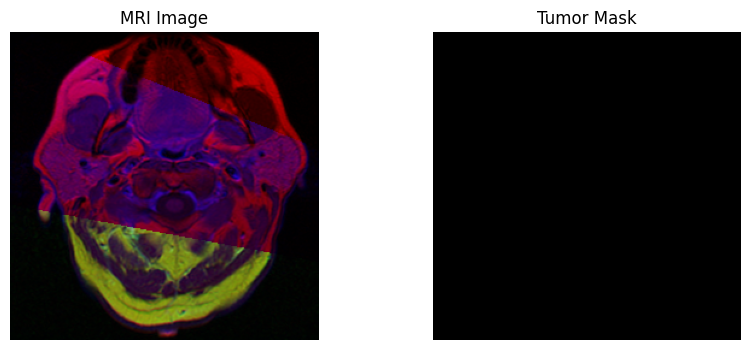

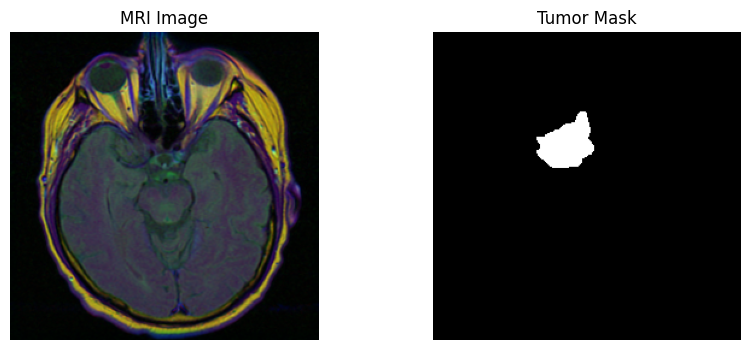

In [ ]:
for i in range(2):

    image = cv2.imread(image_paths[i])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_paths[i], 0)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("MRI Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Tumor Mask")
    plt.axis("off")

    plt.show()

In [ ]:

IMG_SIZE = 256

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)

    img = img / 255.0
    return img


def preprocess_mask(mask_path):
    mask = cv2.imread(mask_path, 0)

    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    mask = mask / 255.0
    mask = (mask > 0.5).astype("float32")

    return mask


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
class ResNet50Encoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        resnet = models.resnet50(pretrained=pretrained)


        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool


        self.layer1 = resnet.layer1  # 256 channels
        self.layer2 = resnet.layer2  # 512
        self.layer3 = resnet.layer3  # 1024
        self.layer4 = resnet.layer4  # 2048

    def forward(self, x):
        x1 = self.conv1(x)
        x1 = self.bn1(x1)
        x1 = self.relu(x1)

        x2 = self.maxpool(x1)
        x2 = self.layer1(x2)

        x3 = self.layer2(x2)

        x4 = self.layer3(x3)

        x5 = self.layer4(x4)

        return x1, x2, x3, x4, x5

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

        self.conv = nn.Sequential(
            nn.Conv2d(out_channels + out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape != skip.shape:
            x = nn.functional.interpolate(x, size=skip.shape[2:])

        x = torch.cat([x, skip], dim=1)

        x = self.conv(x)

        return x

In [ ]:
class ResNet50_UNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        self.encoder = ResNet50Encoder(pretrained=True)


        self.dec4 = DecoderBlock(2048, 1024)
        self.dec3 = DecoderBlock(1024, 512)
        self.dec2 = DecoderBlock(512, 256)
        self.dec1 = DecoderBlock(256, 64)


        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)

        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):


        x1, x2, x3, x4, x5 = self.encoder(x)


        d4 = self.dec4(x5, x4)
        d3 = self.dec3(d4, x3)
        d2 = self.dec2(d3, x2)
        d1 = self.dec1(d2, x1)

        x = self.final_up(d1)
        x = self.final_conv(x)

        return x

In [ ]:
from torch.utils.data import Dataset
import cv2
import torch
import numpy as np

class MRIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=256, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Load Image
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        # 2. Load Mask
        mask = cv2.imread(self.mask_paths[idx], 0)
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        # 3. Apply Data Augmentation (Albumentations applies the same transforms to both)
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # 4. Normalize
        img = img / 255.0
        mask = mask / 255.0
        mask = (mask > 0.5).astype(np.float32)

        # 5. Convert to PyTorch Tensors
        img = torch.tensor(img).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [ ]:
import albumentations as A
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader


train_image_paths, test_image_paths, train_mask_paths, test_mask_paths = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)


train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
])


train_dataset = MRIDataset(train_image_paths, train_mask_paths, img_size=256, transform=train_transform)
test_dataset = MRIDataset(test_image_paths, test_mask_paths, img_size=256, transform=None)


train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

print(f"Total training samples: {len(train_dataset)}")
print(f"Total testing samples: {len(test_dataset)}")

Total training samples: 4241
Total testing samples: 1061


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
from torch.utils.data import DataLoader

dataset = MRIDataset(image_paths, mask_paths)

train_loader = DataLoader(dataset, batch_size=10, shuffle=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet50_UNet(num_classes=1).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


In [ ]:


class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)

        smooth = 1e-6
        intersection = (preds * targets).sum()
        dice = (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)

        return 1 - dice


bce = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(preds, targets):
    return bce(preds, targets) + dice_loss(preds, targets)

In [ ]:
import torch.optim as optim

# Map your custom function to the 'criterion' variable used in the loop
criterion = combined_loss

# Setup the optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 10

for epoch in range(epochs):
    total_loss = 0
    model.train()

    for i, (images, masks) in enumerate(train_loader):
        images = images.to(device)
        masks = masks.to(device)


        outputs = model(images)


        loss = criterion(outputs, masks)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if i % 10 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

    print(f"✅ Epoch {epoch+1} completed | Avg Loss: {total_loss/len(train_loader):.4f}")

In [ ]:
def visualize_predictions(model, dataset, device, index=0):
    """
    Plots original MRI image, True Mask, Predicted Probabilities, and Binary Mask Overlay.
    """
    model.eval()

    # Retrieve data structure
    image, mask = dataset[index]
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_input)
        pred = torch.sigmoid(output)

    # Re-shape tensors to standard NumPy imaging dimensions HWC
    image_np = image.permute(1, 2, 0).cpu().numpy()
    mask_np = mask.squeeze().cpu().numpy()
    pred_np = pred.squeeze().cpu().numpy()
    binary_pred = (pred_np > 0.5).astype(np.float32)

    # Create an image overlay mapping prediction directly on raw MRI data
    overlay = image_np.copy()
    # Mask turns bright red where a tumor is predicted
    overlay[binary_pred == 1] = [1.0, 0.0, 0.0]

    # Build evaluation layout
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image_np)
    plt.title("Original MRI Scan")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mask_np, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_np, cmap='jet')
    plt.title("Model Confidence Map")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(cv2.addWeighted(image_np, 0.7, overlay, 0.3, 0))
    plt.title("Predicted Mask Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def calculate_metrics(pred, mask, threshold=0.5):
    """
    Calculates Dice and IoU scores for a single pair of prediction and mask.
    """
    pred = (pred > threshold).astype(np.float32)
    mask = mask.astype(np.float32)

    intersection = np.sum(pred * mask)
    total_pixels = np.sum(pred) + np.sum(mask)
    union = np.sum((pred + mask) > 0)

    smooth = 1e-8

    # Dice Score (F1-score equivalent)
    dice = (2.0 * intersection + smooth) / (total_pixels + smooth)
    # IoU Score (Jaccard Index)
    iou = (intersection + smooth) / (union + smooth)

    return dice, iou

def evaluate_model(model, dataset, device):

    model.eval()
    dice_scores = []
    iou_scores = []

    for i in range(len(dataset)):
        image, mask = dataset[i]
        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_input)
            pred = torch.sigmoid(output)

        pred = pred.squeeze().cpu().numpy()
        mask = mask.squeeze().cpu().numpy()

        dice, iou = calculate_metrics(pred, mask)
        dice_scores.append(dice)
        iou_scores.append(iou)

    mean_dice = np.mean(dice_scores)
    mean_iou = np.mean(iou_scores)

    print(f"\n--- Validation Results ---")
    print(f"Mean Dice Coefficient: {mean_dice:.4f}")
    print(f"Mean IoU (Jaccard Index): {mean_iou:.4f}")
    return mean_dice, mean_iou

In [ ]:
def evaluate(model, dataset, device):

    model.eval()

    dice_scores = []
    f1_scores = []

    for i in range(len(dataset)):

        image, mask = dataset[i]
        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_input)
            pred = torch.sigmoid(output)

        pred = pred.squeeze().cpu().numpy()
        mask = mask.squeeze().cpu().numpy()

        dice, f1 = dice_f1_score(pred, mask)

        dice_scores.append(dice)
        f1_scores.append(f1)

    print("\n===== MODEL PERFORMANCE =====")
    print(f"Dice Score : {np.mean(dice_scores):.4f}")
    print(f"F1 Score   : {np.mean(f1_scores):.4f}")

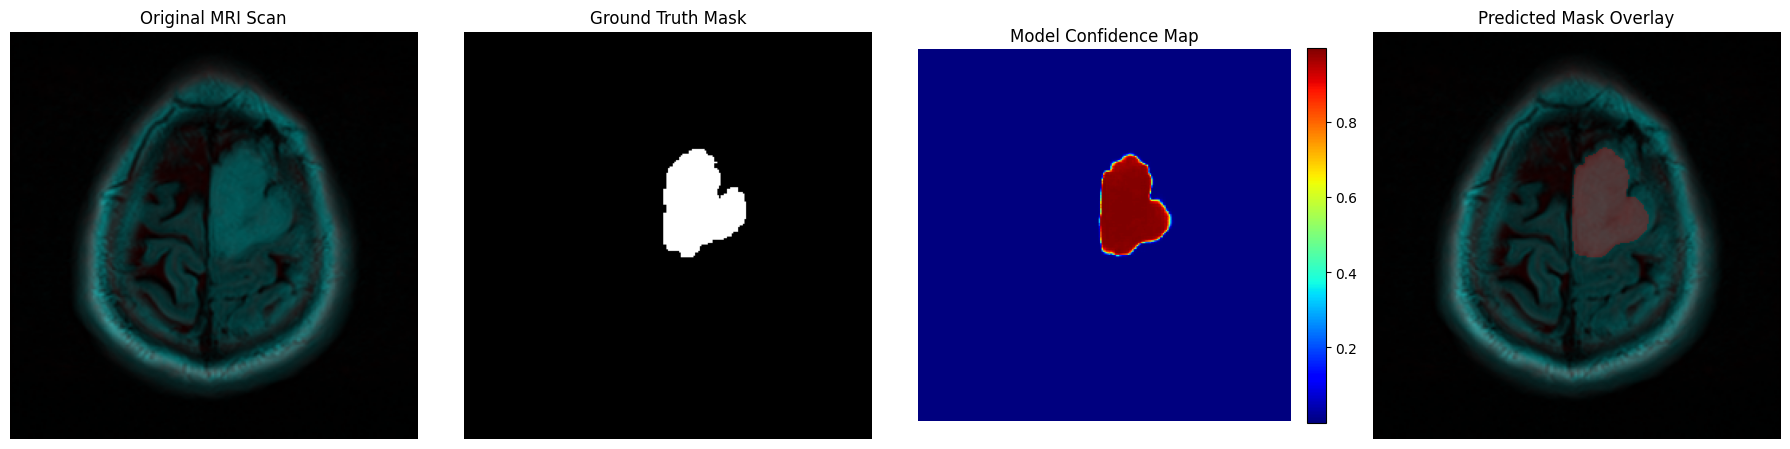


--- Validation Results ---
Mean Dice Coefficient: 0.7950
Mean IoU (Jaccard Index): 0.7578


In [ ]:

visualize_predictions(model, test_dataset, device, index=5)

mean_dice, mean_iou = evaluate_model(model, test_dataset, device)